# **3rd HOMEWORK - Traffic Prediction**
Goal: build and evaluate ANN and LSTM models for cellular traffic prediction, then analyse provisioning costs.

## Input data
Upload `dataset.zip` using the panel in the first cell   

## Workflow
1. **Setup** – setup environment, extract dataset, install dependencies
2. **Preprocessing** – load raw CDR files, aggregate to hourly, generate feature matrices
3. **ANN** – train/test split, model training, performance evaluation
4. **LSTM** – sequential dataset, train/test split, model training, performance evaluation
5. **Homework (Tasks 8a-8c)** – rescale to Gbit/s, provisioning-cost function, 3-D cost surface


In [1]:
from google.colab import files
import zipfile, os

print("Upload 'dataset.zip' using the panel that appears below.")
uploaded = files.upload()

zip_filename = list(uploaded.keys())[0]
EXTRACT_TO   = '/content/'

with zipfile.ZipFile(zip_filename, 'r') as z:
    z.extractall(EXTRACT_TO)

print('Extracted to', EXTRACT_TO)

Upload 'dataset.zip' using the panel that appears below.


Saving dataset.zip to dataset.zip
Extracted to /content/


In [2]:
# =========================
# IMPORTS
# =========================

from numpy.random import seed
seed(1)
from tensorflow.random import set_seed
set_seed(2)

import os
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.utils import plot_model


In [3]:
# =========================
# CONSTANTS
# =========================

# cell used for training/evaluation (task 2b)
CELL_ID      = 5

# first day (Nov 1)
START_DAY    = 1

# full dataset
NUM_DAYS     = 61

# Internet traffic
TRAFFIC_TYPE = 5

# 10 days test set
N_TEST_HOURS = 240

# LSTM lookback (days)
LBD          = 3

# ANN hyper-parameters
ANN_ACTIVATION = 'sigmoid'
ANN_LAYERS     = 3
ANN_NEURONS    = [15, 10, 5]
ANN_EPOCHS     = 500
ANN_BATCH      = 32

# LSTM hyper-parameters
LSTM_LAYERS  = 2
LSTM_NEURONS = [7, 3]
LSTM_EPOCHS  = 50

# Homework constants
MAX_TRAFFIC_GBPS          = 1.0
INTERFACE_GRANULARITY_MBIT = 100

RES_FOLDER = '/content/Results'
os.makedirs(RES_FOLDER, exist_ok=True)
os.makedirs('/content/Preprocessing', exist_ok=True)


In [4]:
# =========================
# FUNCTIONS
# =========================

def load_dataset(cell_id, start_day, num_days, traffic_type):
#Inputs: - cell_id: id of the square cell to consider (an integer in [1-20] or [4991-5010] or [9981-10000])
#        - start_day: first day to include in the dataframe (an integer in [1,61])
#        - num_days: number of consecutive days to include in the dataframe, starting from start_day
#        - traffic_type: either 1) Received SMS, 2) Sent SMS, 3) Incoming Calls, 4) Outgoing Calls, 5) Internet
#Output: - df: dataframe with loaded traffic info (rows are days, columns are hours)
#          Indexes of days must correspond to the selected days
#          (e.g., indexes 36-40 if selecting days Dec. 6th - 10th)

  df = pd.DataFrame(np.zeros([num_days, 24]),
                    index=range(start_day, start_day + num_days),
                    columns=range(24))
  for d in range(start_day, start_day + num_days):
      if d >= 31:
          day, month = str(d - 30).zfill(2), '12'
      else:
          day, month = str(d).zfill(2), '11'

      with open('/content/dataset/short_milan_processed_2013-' + month + '-' + day + '.txt', 'r') as f:
          hour = counter = 0
          for line in f:
              fields = line.split()
              if int(fields[0]) == cell_id:
                  df.loc[d, hour] += float(fields[traffic_type + 1])
                  counter += 1
                  if counter == 6:
                      hour += 1
                      counter = 0
              elif int(fields[0]) > cell_id:
                  break
  return df


def generatedataset(dataset):
#Input:  - dataset: pandas dataframe with traffic profile as loaded in task 1
#Outputs: return X, y, Xdf, ydf,  where:
#         * X (numpy array) is the features matrix where each row is a given hour of a day, repeated for all the hours/days
#           in the dataset, and has the following features:
#               1) 'day_of_week' : 0=monday, 1=tuesday, ...
#               2) 'hour' : hour of the day
#               3) 'working' : binary, =1 if working, =0 if holiday
#               4) 'prev_week' : traffic value for the pevious week in the same day/hour (for the first 7 days of samples, we choose this feature as a copy of the traffic in the first day)
#               5) 'prev_day' : traffic value for the pevious day in the same hour (for the first day of samples, we choose this feature as a copy of the traffic in the first day)
#         * y (numpy array) is the vector of outputs, i.e., it has traffic values for the current day/hour (that we want to predict based on X)
#         * Xdf, ydf are the pandas dataframe versions of X and y

  weekend_vect = np.array([1,2,3,9,10,16,17,23,24,30,31,37,38,44,45,51,52,55,56,58,59])
  days_vect      = list(dataset.index)
  day_hour_vect  = [d for d in days_vect for _ in range(24)]
  day_of_the_week = [(day + 3) % 7 for day in day_hour_vect]
  hour_vect       = [h for _ in days_vect for h in range(24)]
  working_vect    = [0 if d in weekend_vect else 1 for d in days_vect for _ in range(24)]

  prev_week_vect = np.array(dataset.loc[days_vect[0], :])
  prev_day_vect  = np.array(dataset.loc[days_vect[0], :])
  y              = np.array(dataset.loc[days_vect[0], :])

  for i, d in enumerate(days_vect):
      if i == 0:
          continue
      prev_week_vect = np.append(prev_week_vect,
          np.array(dataset.loc[d - 7 if d > days_vect[0] + 6 else d, :]))
      prev_day_vect  = np.append(prev_day_vect,
          np.array(dataset.loc[d - 1 if d > days_vect[0] else d, :]))
      y = np.append(y, np.array(dataset.loc[d, :]))

  Xdf = pd.DataFrame.from_dict({
      'day_of_week': day_of_the_week,
      'hour':        hour_vect,
      'working_day': working_vect,
      'prev_week':   prev_week_vect,
      'prev_day':    prev_day_vect})
  X   = Xdf.to_numpy()
  ydf = pd.DataFrame(data=y, index=list(Xdf.index), columns=['traffic'])
  return X, y, Xdf, ydf


def train_test_split_ANN(X, y, test_hours):
#Inputs:  - X: matrix of features (the numpy ndarray version)
#         - y: outputs vector (the numpy array)
#         - test_hours: number of hours/samples in (X,y) to include in the test set (the remaining hours will be used for training)
#           N.B. each sample in the dataset refers to a single hour of a day
#Outputs: - X_train, X_test, y_train, y_test

  n_train    = X.shape[0] - test_hours
  X_train    = X[:n_train, :]
  X_test     = X[n_train:, :]
  y_train    = y[:n_train]
  y_test     = y[n_train:]

  scaler     = MinMaxScaler(feature_range=(0, 1))
  X_train    = scaler.fit_transform(X_train)
  X_test     = scaler.transform(X_test)

  y_train    = scaler.fit_transform(y_train.reshape(-1, 1))
  y_test     = scaler.transform(y_test.reshape(-1, 1))
  return X_train, X_test, y_train, y_test


def performance_eval(y_true, y_pred, resfig):
#Inputs:  - y_true: ground-truth traffic vector
#         - y_pred: predicted traffic vector
#         - resfig: name of file where to save figure with predicted and ground-truth traffic
#This function should: Compute MSE, MAE and R2-score metrics
#                      Print metrics in output
#                      Plot predicted and ground-truth traffic and save figure in resfig
#                      Return performance metrics
#Outputs: - plot of y_true and y_pred on the same graph
#         - return mse, mae, r2

  mse = mean_squared_error(y_true, y_pred)
  mae = mean_absolute_error(y_true, y_pred)
  r2  = r2_score(y_true, y_pred)

  print('MSE: {}'.format(mse))
  print('MAE: {}'.format(mae))
  print('R2 score: {}'.format(r2))
  FONT_SIZE = 14

  plt.rc('font',   size=FONT_SIZE)
  plt.rc('axes',   titlesize=FONT_SIZE)
  plt.rc('axes',   labelsize=FONT_SIZE)
  plt.rc('xtick',  labelsize=FONT_SIZE)
  plt.rc('ytick',  labelsize=FONT_SIZE)
  plt.rc('legend', fontsize=12)
  plt.rc('figure', titlesize=FONT_SIZE)
  plt.figure()

  plt.plot(y_true,  label='Actual traffic')
  plt.plot(y_pred,  label='Predicted traffic')

  plt.xlabel('Hours')
  plt.ylabel('(Normalized) traffic')
  plt.legend(loc='lower right')
  plt.grid()
  plt.savefig(resfig)
  plt.show()

  return mse, mae, r2


def generatedataset_LSTM(dataset, lookback_days=1):
#Inputs:  - dataset: pandas dataframe with traffic profile as loaded above
#         - lookback_days: no. of days that we want to consider as input to perform prediction with LSTM
#Outputs: - return X, y (matrix X and output y are numpy ndarrays)
#         The i-th element of X is a sequence of lookback_days*24 hourly traffic traces, and the corresponding
#         i-th element of y is the predicted traffic for the following hour

  unrolled  = np.array(dataset).reshape(-1, 1)
  lookback  = int(lookback_days * 24)
  X, y = [], []
  for i in range(len(unrolled)):
      end = i + lookback
      if end > len(unrolled) - 1:
          break
      X.append(unrolled[i:end])
      y.append(unrolled[end])
  return np.array(X), np.array(y)


def train_test_split_LSTM(X, y, test_hours, day_gap):
#Inputs:  - X: matrix of features (for each element, a series of traffic values of length lookback_days*24)
#         - y: outputs vector (for each element, the value of traffic to be predicted for the next hour)
#         - test_hours: number of hours/samples in (X,y) to include in the test set
#         - day_gap: no. of days that we want to consider as separation between train and test sets
#               Setting day_gap=0 means that 1st element of y_test is the traffic for subsequent hour wrt last element in y_train
#               Note that with day_gap=0, we will include in X_test traffic info used as output in training phase (they are also in y_train)
#Outputs: return X_train, X_test, y_train, y_test


  Xx, yy    = X.copy(), y.copy()
  gap       = int(day_gap * 24)
  n_train   = Xx.shape[0] - test_hours - gap
  test_start = n_train + gap
  X_train   = Xx[:n_train]
  y_train   = yy[:n_train]
  X_test    = Xx[test_start:]
  y_test    = yy[test_start:]

  scaler    = MinMaxScaler(feature_range=(0, 1))
  X_train[:, :, 0] = scaler.fit_transform(X_train[:, :, 0])
  X_test[:, :, 0]  = scaler.transform(X_test[:, :, 0])

  y_train   = scaler.fit_transform(y_train.reshape(-1, 1))
  y_test    = scaler.transform(y_test.reshape(-1, 1))

  return X_train, X_test, y_train, y_test


def evaluate_cost(ytrue, ypredANN, ypredLSTM, alpha, beta):
#Inputs:  - ytrue: ground-truth traffic
#         - ypredANN: ANN-predicted traffic
#         - ypredLSTM: LSTM-predicted traffic
#         - alpha, beta: scalar parameters that weight over- and under-provisioning costs, respectively
#Outputs: return costANN, costLSTM
#     To generate costs above, assume that an operator allocates interfaces with 100 Mbit/s granularity
#     (e.g., if predicted traffic is 440 Mbit/s, then 5 interfaces are needed).
#     Then, over/under-provisioning costs are calculated weighting the difference between ground truth
#     and predicted interfaces with parameters alpha and beta in input used to weigh over/under-provisioning.
#     N.B. Over-provisioning cost can be due to (e.g.) unnecessary power consumption;
#     under-provisioning cost can be due to (e.g.) blocked traffic

  # Convert Gbit/s -> Mbit/s, then allocate with 100 Mbit/s granularity
  ytrue_mbit    = np.array(ytrue).flatten()    * 1000
  ypredANN_mbit = np.array(ypredANN).flatten() * 1000
  ypredLSTM_mbit= np.array(ypredLSTM).flatten()* 1000

  def _cost(pred_mbit, true_mbit, a, b):
      total = 0.0
      for p, t in zip(pred_mbit, true_mbit):
          iface_pred = math.ceil(p / INTERFACE_GRANULARITY_MBIT)
          iface_true = math.ceil(t / INTERFACE_GRANULARITY_MBIT)
          diff = iface_pred - iface_true
          # over-provisioning
          if diff > 0:
              total += a * diff
          # under-provisioning
          elif diff < 0:
              total += b * (-diff)
      return total

  costANN  = _cost(ypredANN_mbit,  ytrue_mbit, alpha, beta)
  costLSTM = _cost(ypredLSTM_mbit, ytrue_mbit, alpha, beta)

  return costANN, costLSTM


In [5]:
# ==============================
# LOAD DATASET + GENERATE FEATURES (Task 2b)
# ==============================

dataframe = load_dataset(CELL_ID, START_DAY, NUM_DAYS, TRAFFIC_TYPE)

X, y, Xdata, ydata = generatedataset(dataframe)
print('X shape:', X.shape)
print('y shape:', y.shape)

for i in range(X.shape[1]):
    print('Feature {:12s}  min={:.2f}  max={:.2f}'.format(
        Xdata.columns[i], X[:, i].min(), X[:, i].max()))


X shape: (1464, 5)
y shape: (1464,)
Feature day_of_week   min=0.00  max=6.00
Feature hour          min=0.00  max=23.00
Feature working_day   min=0.00  max=1.00
Feature prev_week     min=24.87  max=152.20
Feature prev_day      min=24.87  max=152.20


In [6]:
# ==============================
# ANN TRAIN / TEST SPLIT (Task 3b)
# ==============================

X_train, X_test, y_train, y_test = train_test_split_ANN(X, y, N_TEST_HOURS)

print('Whole dataset  X:{} y:{}'.format(X.shape, y.shape))
print('Train          X:{} y:{}'.format(X_train.shape, y_train.shape))
print('Test           X:{} y:{}'.format(X_test.shape, y_test.shape))


Whole dataset  X:(1464, 5) y:(1464,)
Train          X:(1224, 5) y:(1224, 1)
Test           X:(240, 5) y:(240, 1)


In [7]:
# ==============================
# ANN TRAINING (Task 4a)
# ==============================

print('Fitting ANN: activation={}, layers={}, neurons={}'.format(
    ANN_ACTIVATION, ANN_LAYERS, ANN_NEURONS))

model_NN = Sequential()
model_NN.add(Dense(ANN_NEURONS[0], activation=ANN_ACTIVATION,
                   input_dim=X_train.shape[1]))
for i in range(1, ANN_LAYERS):
    model_NN.add(Dense(ANN_NEURONS[i], activation=ANN_ACTIVATION))
model_NN.add(Dense(1))
model_NN.compile(optimizer='adam', loss='mean_squared_error')

t0 = time.time()
model_NN.fit(X_train, y_train, epochs=ANN_EPOCHS, batch_size=ANN_BATCH, verbose=False)
training_time_NN = round(time.time() - t0, 2)

y_hat_NN = model_NN.predict(X_train)
print('Training duration [s]: {}'.format(training_time_NN))
print('Training MSE: {:.6f}'.format(mean_squared_error(y_train, y_hat_NN)))

plot_model(model_NN, RES_FOLDER + '/ANN_structure.png', show_shapes=True)
model_NN.summary()


Fitting ANN: activation=sigmoid, layers=3, neurons=[15, 10, 5]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Training duration [s]: 63.76
Training MSE: 0.002654


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 15)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 935 (3.66 KB)

 Trainable params: 311 (1.21 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 624 (2.44 KB)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
MSE: 0.00484072806032903
MAE: 0.05168937533355478
R2 score: 0.725164324825823


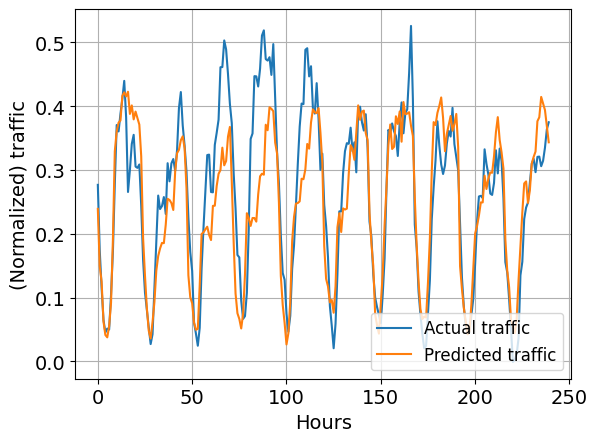

In [8]:
# ==============================
# ANN EVALUATION (Task 4c)
# ==============================

y_pred_ANN = model_NN.predict(X_test)
mse_ANN, mae_ANN, r2_ANN = performance_eval(y_test, y_pred_ANN,
                                             RES_FOLDER + '/ANN_pred.png')


In [9]:
# ==============================
# LSTM DATASET (Task 5b)
# ==============================

XL, yL = generatedataset_LSTM(dataframe, LBD)
print('XL shape:', XL.shape)
print('yL shape:', yL.shape)

# Consistency check
failed = sum(1 for t in range(len(yL) - 1) if yL[t] != XL[t + 1][-1])
print('Consistency check failures:', failed)


XL shape: (1392, 72, 1)
yL shape: (1392, 1)
Consistency check failures: 0


In [10]:
# ==============================
# LSTM TRAIN / TEST SPLIT (Task 6b)
# ==============================

X_train_LSTM, X_test_LSTM, y_train_LSTM, y_test_LSTM = \
    train_test_split_LSTM(XL, yL, N_TEST_HOURS, LBD)

print('Whole LSTM dataset  X:{} y:{}'.format(XL.shape, yL.shape))
print('Train               X:{} y:{}'.format(X_train_LSTM.shape, y_train_LSTM.shape))
print('Test                X:{} y:{}'.format(X_test_LSTM.shape, y_test_LSTM.shape))


Whole LSTM dataset  X:(1392, 72, 1) y:(1392, 1)
Train               X:(1080, 72, 1) y:(1080, 1)
Test                X:(240, 72, 1) y:(240, 1)


In [11]:
# ==============================
# LSTM TRAINING (Task 7a)
# ==============================

print('Fitting LSTM: layers={}, neurons={}'.format(LSTM_LAYERS, LSTM_NEURONS))

model_LSTM = Sequential()
model_LSTM.add(LSTM(LSTM_NEURONS[0], return_sequences=True,
                    input_shape=(int(LBD * 24), 1)))
model_LSTM.add(LSTM(LSTM_NEURONS[1], return_sequences=False))
model_LSTM.add(Dense(1))
model_LSTM.compile(optimizer='adam', loss='mean_squared_error')

t0 = time.time()
model_LSTM.fit(X_train_LSTM, y_train_LSTM, epochs=LSTM_EPOCHS, verbose=False)
training_time_LSTM = round(time.time() - t0, 2)

y_hat_LSTM = model_LSTM.predict(X_train_LSTM)
print('Training duration [s]: {}'.format(training_time_LSTM))
print('Training MSE: {:.6f}'.format(mean_squared_error(y_train_LSTM, y_hat_LSTM)))

plot_model(model_LSTM, RES_FOLDER + '/LSTM_structure.png', show_shapes=True)
model_LSTM.summary()


Fitting LSTM: layers=2, neurons=[7, 3]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Training duration [s]: 75.73
Training MSE: 0.002817


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 72, 7)          │           252 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 3)              │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,166 (4.56 KB)

 Trainable params: 388 (1.52 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 778 (3.04 KB)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
MSE: 0.0027198107863258244
MAE: 0.042253650993397396
R2 score: 0.8455808662478226


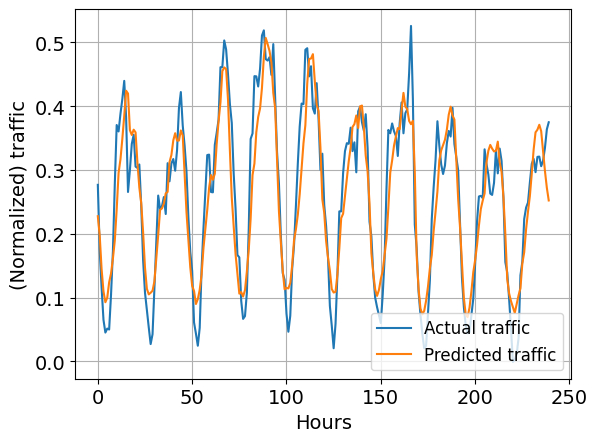

In [12]:
# ==============================
# LSTM EVALUATION (Task 7b)
# ==============================

y_pred_LSTM = model_LSTM.predict(X_test_LSTM)
mse_LSTM, mae_LSTM, r2_LSTM = performance_eval(y_test_LSTM, y_pred_LSTM,
                                               RES_FOLDER + '/LSTM_pred.png')


CDR dataset  min=24.78  max=152.20
Ground truth  min=0.1628 Gbit/s  max=0.6033 Gbit/s
ANN predicted min=0.1857 Gbit/s  max=0.5170 Gbit/s
LSTM predicted min=0.2215 Gbit/s  max=0.5875 Gbit/s


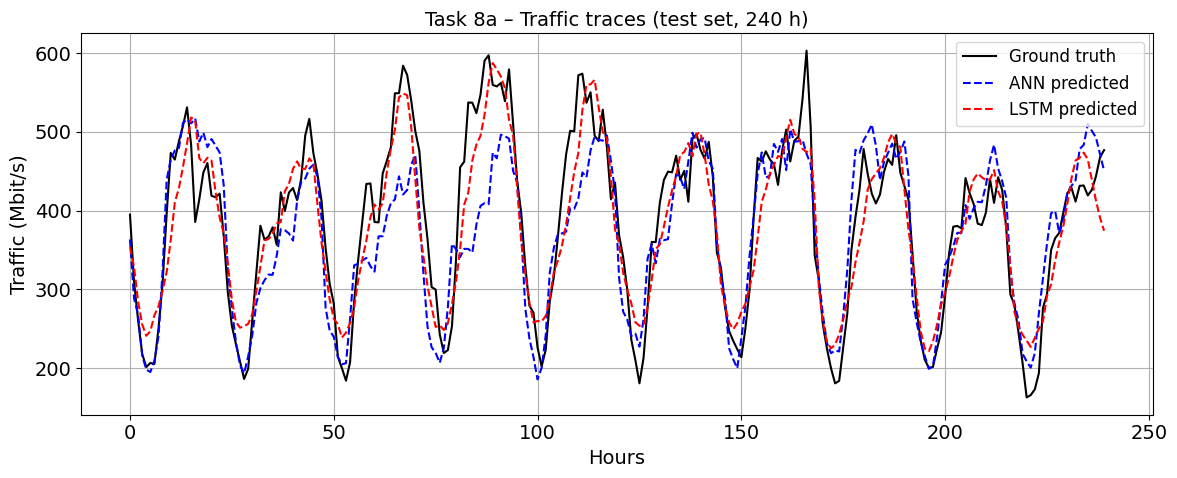

In [13]:
# ==============================
# TASK 8a – Scale to Gbit/s and plot
# ==============================

# Min/max of the CDR dataset
max_cdr = dataframe.values.max()
min_cdr = dataframe.values.min()
print('CDR dataset  min={:.2f}  max={:.2f}'.format(min_cdr, max_cdr))

train_end = len(y) - N_TEST_HOURS
mintraffic = y[:train_end].min()
maxtraffic = y[:train_end].max()

def normalized_to_gbps(y_norm):
    y_cdr = np.asarray(y_norm).reshape(-1) * (maxtraffic - mintraffic) + mintraffic
    return y_cdr / maxtraffic * MAX_TRAFFIC_GBPS

y_true_gbps = normalized_to_gbps(y_test)
y_ann_gbps = normalized_to_gbps(y_pred_ANN)
y_lstm_gbps = normalized_to_gbps(y_pred_LSTM)

# Align lengths (ANN and LSTM test sets are both N_TEST_HOURS samples)
n = min(len(y_true_gbps), len(y_lstm_gbps))
y_true_gbps = y_true_gbps[-n:]
y_ann_gbps  = y_ann_gbps[-n:]
y_lstm_gbps = y_lstm_gbps[-n:]

print('Ground truth  min={:.4f} Gbit/s  max={:.4f} Gbit/s'.format(
    y_true_gbps.min(), y_true_gbps.max()))
print('ANN predicted min={:.4f} Gbit/s  max={:.4f} Gbit/s'.format(
    y_ann_gbps.min(),  y_ann_gbps.max()))
print('LSTM predicted min={:.4f} Gbit/s  max={:.4f} Gbit/s'.format(
    y_lstm_gbps.min(), y_lstm_gbps.max()))

plt.figure(figsize=(12, 5))
plt.plot(y_true_gbps * 1000, color='black',  label='Ground truth')
plt.plot(y_ann_gbps * 1000,  color='blue',   linestyle='--', label='ANN predicted')
plt.plot(y_lstm_gbps * 1000, color='red',    linestyle='--', label='LSTM predicted')
plt.xlabel('Hours')
plt.ylabel('Traffic (Mbit/s)')
plt.title('Task 8a – Traffic traces (test set, {} h)'.format(n))
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(RES_FOLDER + '/task8a_traces.png')
plt.show()


In [14]:
# ==============================
# TASK 8b – Provisioning cost (alpha=1, beta=5 as example)
# ==============================

alpha_ex, beta_ex = 1.0, 5.0
costANN_ex, costLSTM_ex = evaluate_cost(y_true_gbps, y_ann_gbps, y_lstm_gbps,
                                        alpha_ex, beta_ex)
print('alpha={}, beta={}'.format(alpha_ex, beta_ex))
print('Cost ANN  : {:.2f}'.format(costANN_ex))
print('Cost LSTM : {:.2f}'.format(costLSTM_ex))


alpha=1.0, beta=5.0
Cost ANN  : 372.00
Cost LSTM : 243.00


/tmp/ipykernel_11650/2808155736.py:88: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


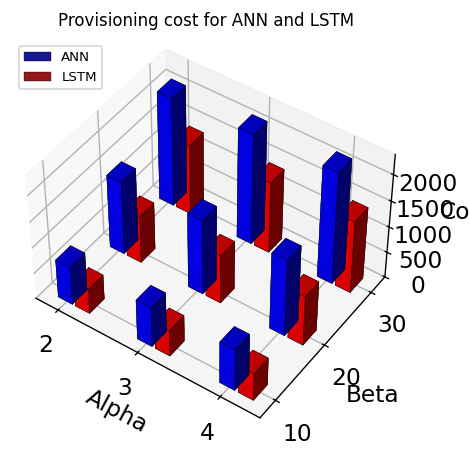

In [15]:
# ==============================
# TASK 8c – 3-D bar plot
# ==============================

alpha_vals = np.array([2, 3, 4])
beta_vals  = np.array([10, 20, 30])

cost_ann = []
cost_lstm = []
xs = []
ys = []

for beta in beta_vals:
    for alpha in alpha_vals:
        ca, cl = evaluate_cost(
            y_true_gbps,
            y_ann_gbps,
            y_lstm_gbps,
            alpha,
            beta
        )
        xs.append(alpha)
        ys.append(beta)
        cost_ann.append(ca)
        cost_lstm.append(cl)

xs = np.array(xs)
ys = np.array(ys)
cost_ann = np.array(cost_ann)
cost_lstm = np.array(cost_lstm)

# categorical positions
x_cat = np.array([np.where(alpha_vals == a)[0][0] for a in xs])
y_cat = np.array([np.where(beta_vals == b)[0][0] for b in ys])

fig = plt.figure(figsize=(5.5, 4.2), dpi=120)
ax = fig.add_subplot(111, projection='3d')

dx = 0.18
dy = 0.28
offset = 0.11

# ANN bars
ax.bar3d(
    x_cat - offset, y_cat - dy/2, np.zeros_like(cost_ann),
    dx, dy, cost_ann,
    color='blue',
    edgecolor='black',
    linewidth=0.2,
    alpha=0.9,
    shade=True,
    label='ANN'
)

# LSTM bars
ax.bar3d(
    x_cat + offset, y_cat - dy/2, np.zeros_like(cost_lstm),
    dx, dy, cost_lstm,
    color='red',
    edgecolor='black',
    linewidth=0.2,
    alpha=0.9,
    shade=True,
    label='LSTM'
)

ax.set_xlabel('Alpha', labelpad=5)
ax.set_ylabel('Beta', labelpad=5)
ax.set_zlabel('Cost', labelpad=5)

ax.set_xticks(range(len(alpha_vals)))
ax.set_xticklabels(alpha_vals)

ax.set_yticks(range(len(beta_vals)))
ax.set_yticklabels(beta_vals)

ax.set_zlim(0, max(cost_ann.max(), cost_lstm.max()) * 1.10)

# più simile allo screenshot piccolo
ax.view_init(elev=45, azim=-55)

# proporzioni più compatte
ax.set_box_aspect((1.2, 1.0, 0.75))

ax.legend(loc='upper left', fontsize=8)
ax.set_title('Provisioning cost for ANN and LSTM', fontsize=10, pad=8)

plt.tight_layout()
plt.show()

## Comments on the obtained results

**Task 8a** Both ANN and LSTM follow the ground-truth traffic trend over the 10-day test window. The ANN tends to produce smoother predictions, while the LSTM captures peak variations more closely in several intervals.

**Task 8b / 8c** The provisioning cost increases with both alpha and beta, since they penalise over- and under-provisioning errors respectively. When **beta > alpha**, under-provisioning becomes more expensive and dominates the total cost.

For the tested combinations, the LSTM consistently yields a lower provisioning cost than the ANN. For example, with **alpha = 1** and **beta = 5** the costs are **ANN = 372** and **LSTM = 243**. The 3-D bar plot confirms this trend across the full (alpha, beta) grid.